### Extrapolate using most plausible models discovered.

In [2]:
# setup
import datetime

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 8))
np.set_printoptions(precision=4, suppress=False)
# please show all columns
pd.set_option("display.max_columns", 60)
import seaborn as sns
sns.set()

# Import sklearn stuff

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline,  make_pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor

In [1]:
# load up
dfMod = pd.read_csv('../local/data/LBNL_openpv_tts_data/model_data_2.csv',
                    index_col='row_id',
                    parse_dates=['install_date'])

NameError: name 'pd' is not defined

In [3]:
# look at some rows
dfMod.sample(n=3).head()

,num_days,num_weeks,num_months,size_kw,scaleSize,state,cost_per_watt,install_date
row_id,,,,,,,,
1012029,6810.0,973.0,224.0,2.900,1.0,TX,2.555862,2016-09-01
150440,4857.0,694.0,159.0,3.995,1.0,CA,6.148936,2011-04-28
1024664,6830.0,976.0,224.0,3.780,1.0,MA,4.351587,2016-09-21


In [4]:
dfMod.install_date.iloc[0], dfMod.install_date.iloc[-1]

(Timestamp('1998-01-09 00:00:00'), Timestamp('2016-12-31 00:00:00'))

#### Data begins 1998-01-09 and ends 2016-12-31; 19 years

In [5]:
19*365

6935

#### Ranges of the time variables

In [6]:
print(dfMod.iloc[-1, :][['num_days', 'num_weeks', 'num_months']])

num_days      6931
num_weeks      990
num_months     227
Name: 1094908, dtype: object


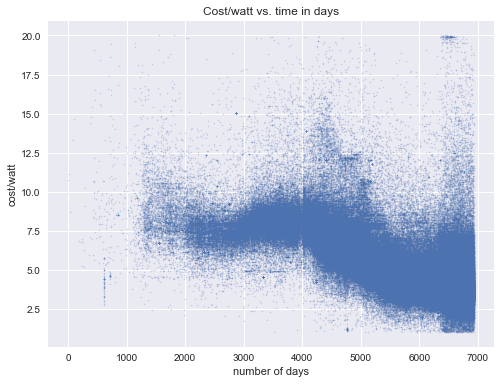

In [7]:
# plot the data
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'Cost/watt vs. time in days'

ax.set_title(sTitle)
ax.scatter(dfMod.num_days, dfMod.cost_per_watt,
               marker='.', s=6, alpha=0.2)
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

#### One-hot encode state and shuffle data (remove time ordering, for train_test_split).

In [8]:
dfMod = pd.get_dummies(dfMod.sample(frac=1.0), drop_first=True); dfMod.head(3)

,num_days,num_weeks,num_months,size_kw,scaleSize,cost_per_watt,install_date,state_AZ,state_CA,state_CT,state_DE,state_FL,state_MA,state_MD,state_MN,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OR,state_PA,state_TX,state_VT,state_WI
row_id,,,,,,,,,,,,,,,,,,,,,,,,,
36773,3539.0,506.0,116.0,5.670,2.0,8.146661,2007-09-18,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
204,722.0,103.0,24.0,7.848,3.0,4.587156,2000-01-01,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
327117,5690.0,813.0,187.0,4.080,1.0,5.150000,2013-08-08,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
dfMod.columns

Index(['num_days', 'num_weeks', 'num_months', 'size_kw', 'scaleSize',
       'cost_per_watt', 'install_date', 'state_AZ', 'state_CA', 'state_CT',
       'state_DE', 'state_FL', 'state_MA', 'state_MD', 'state_MN', 'state_NH',
       'state_NJ', 'state_NM', 'state_NV', 'state_NY', 'state_OR', 'state_PA',
       'state_TX', 'state_VT', 'state_WI'],
      dtype='object')

#### load prediction data

In [10]:
predData = pd.read_csv('mod_pred_data.csv', index_col=0)

In [11]:
predData.columns

Index(['num_days', 'num_weeks', 'num_months', 'size_kw', 'scaleSize',
       'state_AZ', 'state_CA', 'state_CT', 'state_DE', 'state_FL', 'state_MA',
       'state_MD', 'state_MN', 'state_NH', 'state_NJ', 'state_NM', 'state_NV',
       'state_NY', 'state_OR', 'state_PA', 'state_TX', 'state_VT', 'state_WI'],
      dtype='object')

---
---

---
## OLS regression with linear model of cost vs. time for baseline
---

In [56]:
# features: num_days
X = dfMod[['num_days']]
y = dfMod[['cost_per_watt']]

R^2: 0.4043
RMSE: 1.6562


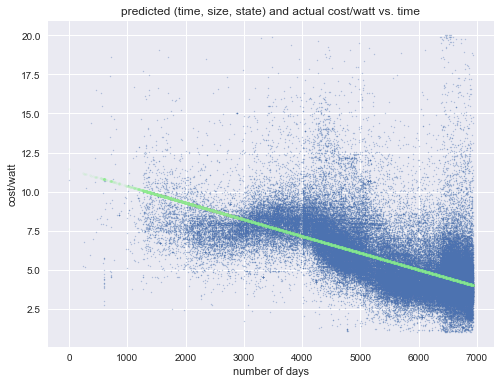

In [57]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42)
# Instantiate the regressor
linReg = LinearRegression()
# Train the model
linReg.fit(X_train, y_train)
# Predict on the test set
yhat = linReg.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(linReg.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("RMSE: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'predicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
ax.scatter(X_test.num_days, y_test, marker='.', s=5, alpha=0.3,)
ax.scatter(X_test.num_days, linReg.predict(X_test), s=4, alpha=0.1, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

In [58]:
print(linReg.coef_, linReg.intercept_)

[[-0.0011]] [11.4328]


#### predict on data including time extrapolation

In [61]:
theX=predData[['num_days']]

In [62]:
theY = linReg.predict(theX)

### Extrapolate 2017 and 2018

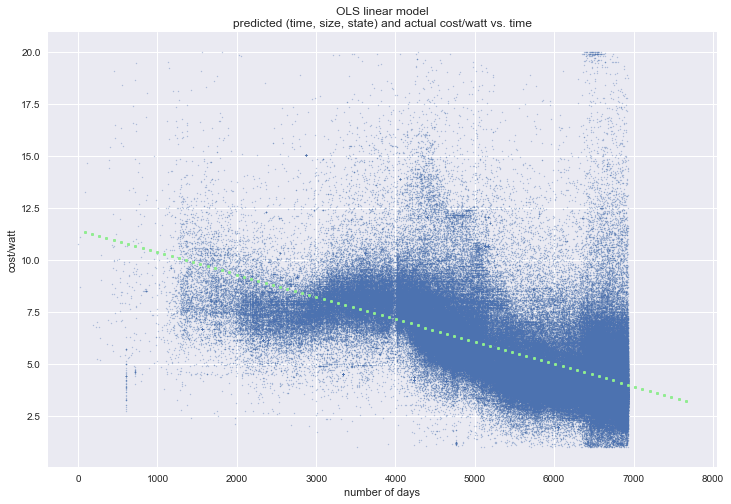

In [63]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'OLS linear model\npredicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_days, y, marker='.', s=5, alpha=0.3,)
# predicted
ax.scatter(theX.num_days, theY, s=4, alpha=1.0, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

---
## OLS regression with linear model of time, size and state for baseline
---

In [12]:
# features: state, num_days and size_kw 
X = dfMod.drop(['num_weeks', 'num_months', 'scaleSize', 'cost_per_watt', 'install_date'], axis='columns')
y = dfMod[['cost_per_watt']]

R^2: 0.4613
RMSE: 1.5750


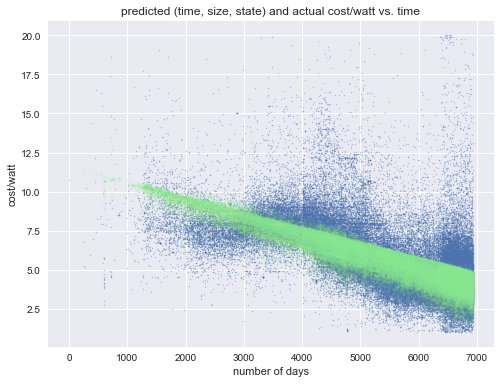

In [13]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42)
# Instantiate the regressor
linReg = LinearRegression()
# Train the model
linReg.fit(X_train, y_train)
# Predict on the test set
yhat = linReg.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(linReg.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("RMSE: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'predicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
ax.scatter(X_test.num_days, y_test, marker='.', s=5, alpha=0.3,)
ax.scatter(X_test.num_days, linReg.predict(X_test), s=4, alpha=0.1, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

In [14]:
print(linReg.coef_, linReg.intercept_)

[[-9.8964e-04 -1.3007e-01 -8.9273e-01 -1.0666e-01 -4.8782e-01 -2.5221e-01
   1.2734e-02 -2.0498e-01 -3.0955e-02  3.4801e-01 -8.6113e-01  6.2686e-01
  -4.2536e-01 -7.6381e-01 -2.5229e-01 -4.3040e-01 -1.1870e-01 -1.0445e+00
  -8.4172e-01 -5.2352e-01]] [11.9971]


#### predict on data including time extrapolation

In [15]:
theX=predData.drop(['num_weeks', 'num_months', 'scaleSize'], axis='columns')

In [16]:
theY = linReg.predict(theX)

### Extrapolate 2017 and 2018

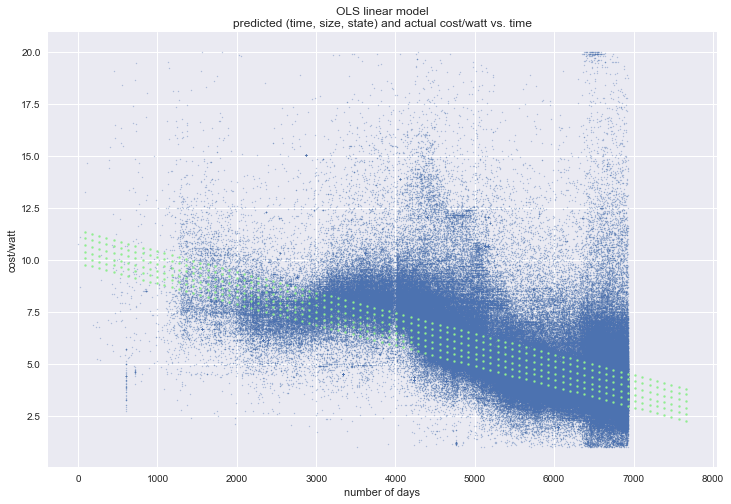

In [17]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'OLS linear model\npredicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_days, y, marker='.', s=5, alpha=0.3,)
# predicted
ax.scatter(theX.num_days, theY, s=4, alpha=1.0, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

---
---

---
## OLS with best polynomial model, cost ~ time, size, state
---

#### Make pipeline to build features

In [18]:
### make it an estimator and a transformer for general use
class ColumnExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_cols = X[self.columns]
        return X_cols

In [19]:
# first, add LR to the pipeline
# take the data apart; numerical vars get scaled, then go to polynomial; state dummies pass through; 
# they get glued back together for the regression.
theStates = ['state_AZ', 'state_CA', 'state_CT', 'state_DE', 'state_FL', 'state_MA',
             'state_MD', 'state_MN', 'state_NH', 'state_NJ', 'state_NM', 'state_NV',
             'state_NY', 'state_OR', 'state_PA', 'state_TX', 'state_VT', 'state_WI']

thePipe = Pipeline([
    ('features', 
     FeatureUnion([('num_vars', 
                    Pipeline([('extract', ColumnExtractor(columns=['num_days', 'size_kw'])),
                              ('scale', StandardScaler()),
                              ('poly', PolynomialFeatures())
                              ])),
                   ('cat_vars',
                    ColumnExtractor(columns=theStates))
                  ]) # end of FeatureUnion
    ),
    ('LR', LinearRegression())
]) # end of Pipeline

In [20]:
thePipe.get_params().keys()

dict_keys(['memory', 'steps', 'features', 'LR', 'features__n_jobs', 'features__transformer_list', 'features__transformer_weights', 'features__num_vars', 'features__cat_vars', 'features__num_vars__memory', 'features__num_vars__steps', 'features__num_vars__extract', 'features__num_vars__scale', 'features__num_vars__poly', 'features__num_vars__extract__columns', 'features__num_vars__scale__copy', 'features__num_vars__scale__with_mean', 'features__num_vars__scale__with_std', 'features__num_vars__poly__degree', 'features__num_vars__poly__include_bias', 'features__num_vars__poly__interaction_only', 'features__cat_vars__columns', 'LR__copy_X', 'LR__fit_intercept', 'LR__n_jobs', 'LR__normalize'])

In [21]:
# features: state, num_days and size_kw 
X = dfMod.drop(['num_weeks', 'num_months', 'scaleSize', 'cost_per_watt', 'install_date'], axis='columns')
y = dfMod[['cost_per_watt']]

R^2: 0.5291
RMSE: 1.4725


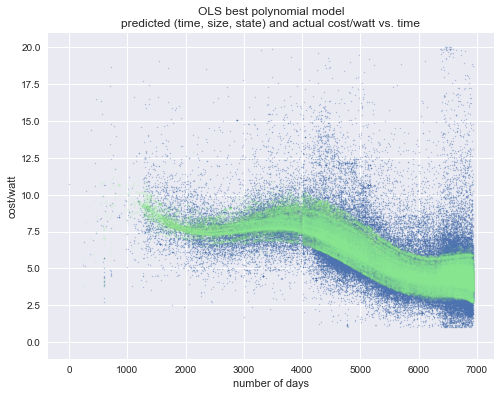

In [22]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42)
# Instantiate the regressor
olsPoly = thePipe
# the best poly degree from grid search
olsPoly.set_params(features__num_vars__poly__degree=6)
# Train the model
olsPoly.fit(X_train, y_train)
# Predict on the test set
yhat = olsPoly.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(olsPoly.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("RMSE: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'OLS best polynomial model\npredicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
ax.scatter(X_test.num_days, y_test, marker='.', s=5, alpha=0.3,)
ax.scatter(X_test.num_days, olsPoly.predict(X_test), s=4, alpha=0.1, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

#### Extrapolate 2017 and 2018

In [23]:
theX=predData.drop(['num_weeks', 'num_months', 'scaleSize'], axis='columns')

In [24]:
theX.columns

Index(['num_days', 'size_kw', 'state_AZ', 'state_CA', 'state_CT', 'state_DE',
       'state_FL', 'state_MA', 'state_MD', 'state_MN', 'state_NH', 'state_NJ',
       'state_NM', 'state_NV', 'state_NY', 'state_OR', 'state_PA', 'state_TX',
       'state_VT', 'state_WI'],
      dtype='object')

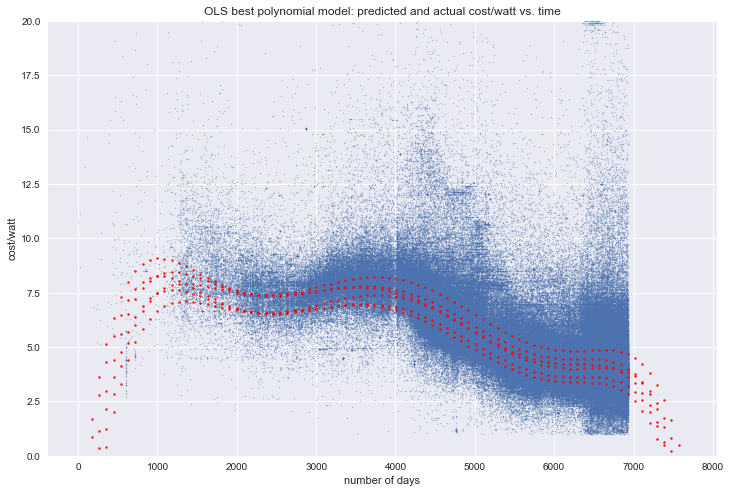

In [25]:
theY = olsPoly.predict(theX)

# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'OLS best polynomial model: predicted and actual cost/watt vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_days, y, marker='.', s=5, alpha=0.3,)
# predicted
ax.scatter(theX.num_days, theY, s=4, alpha=1.0, color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
ax.set_ylim(0,20)
plt.show();

---
---

---
## Random Forest Regressor with best parameters
---

In [69]:
# features: state, num_days and size_kw 
X = dfMod.drop(['num_weeks', 'num_months', 'scaleSize', 'cost_per_watt', 'install_date'], axis='columns')
y = dfMod[['cost_per_watt']]

In [70]:
X.columns

Index(['num_days', 'size_kw', 'state_AZ', 'state_CA', 'state_CT', 'state_DE',
       'state_FL', 'state_MA', 'state_MD', 'state_MN', 'state_NH', 'state_NJ',
       'state_NM', 'state_NV', 'state_NY', 'state_OR', 'state_PA', 'state_TX',
       'state_VT', 'state_WI'],
      dtype='object')

C:\Users\saus\Anaconda3\lib\site-packages\ipykernel_launcher.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  


R^2: 0.5993
RMSE: 1.3491


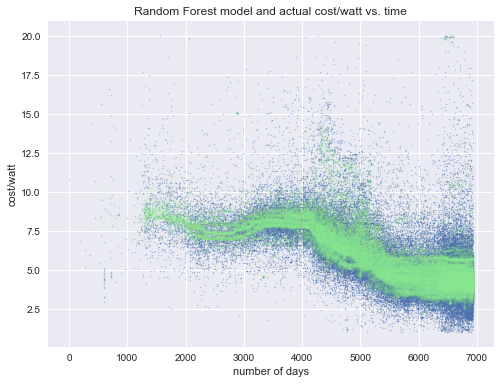

In [71]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=21)
# Instantiate the regressor
rfr = RandomForestRegressor()
# set best parameters
rfr.set_params(n_estimators=20, max_depth=15)
# Train the model
rfr.fit(X_train, y_train)
# Predict on the test set
yhat = rfr.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(rfr.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("RMSE: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'Random Forest model and actual cost/watt vs. time'
ax.set_title(sTitle)
ax.scatter(X_test.num_days, y_test, marker='.', s=5, alpha=0.3,)
ax.scatter(X_test.num_days, rfr.predict(X_test), s=4, alpha=0.1, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

#### predict on data including time extrapolation, 3 sizes and 2 states

In [28]:
theX=predData.drop(['num_weeks', 'num_months', 'scaleSize'], axis='columns')

In [29]:
theY = rfr.predict(theX)

###  Extrapolate RFR for 2017 and 2018

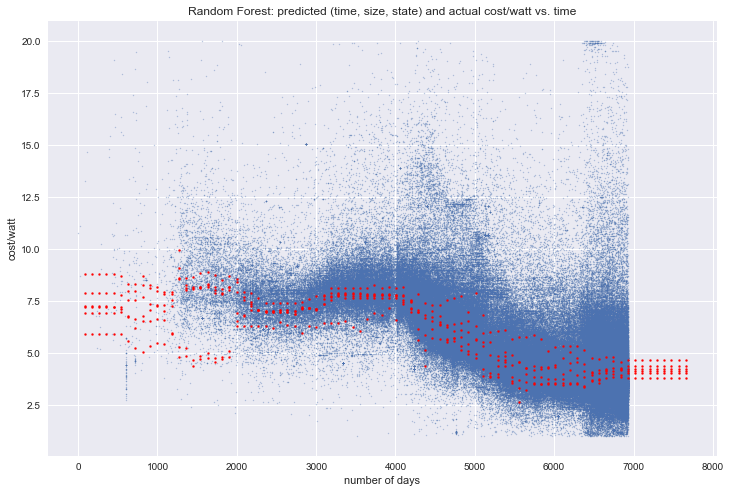

In [30]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'Random Forest: predicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_days, y, marker='.', s=5, alpha=0.3,)
# predicted
ax.scatter(theX.num_days, theY, s=4, alpha=1.0, color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

---
---

---

## OLS polynomial model of median cost/watt (1 feature, time in weeks)

---

In [31]:
# get the median cost/watt by week
by_week = dfMod.groupby(['num_weeks'])
median_week = by_week.cost_per_watt.median()

In [32]:
median_week.head()

num_weeks
0.0     10.734315
3.0     11.108701
4.0      8.667013
12.0    13.270286
16.0    14.654839
Name: cost_per_watt, dtype: float64

In [33]:
# make a poly expansion of median (8th degree)
medW = Pipeline([('scale', StandardScaler()), 
                       ('poly', PolynomialFeatures()),
                       ('LR', LinearRegression())
                    ])

In [34]:
medW.set_params(poly__degree=8)

Pipeline(memory=None,
     steps=[('scale', StandardScaler(copy=True, with_mean=True, with_std=True)), ('poly', PolynomialFeatures(degree=8, include_bias=True, interaction_only=False)), ('LR', LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False))])

In [35]:
# transform time (num_weeks) to create X
X = median_week.index.values.reshape(-1, 1)
y = median_week.values.reshape(-1, 1)

In [36]:
# Create training and test sets and hand it the scaled and poly-expanded data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=21)

In [37]:
# Train the model
medW.fit(X_train, y_train)

Pipeline(memory=None,
     steps=[('scale', StandardScaler(copy=True, with_mean=True, with_std=True)), ('poly', PolynomialFeatures(degree=8, include_bias=True, interaction_only=False)), ('LR', LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False))])

In [38]:
# Predict on the test set
yhat = medW.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(medW.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("RMSE: {:.4f}".format(rmse))

R^2: 0.8341
RMSE: 0.7355


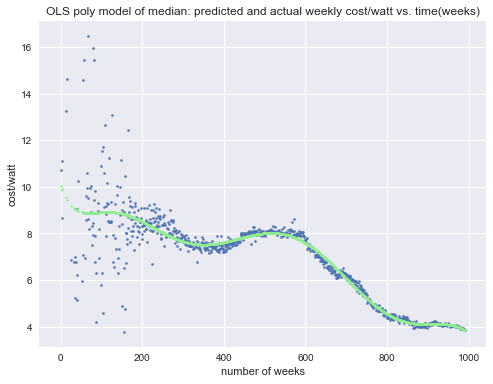

In [39]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'OLS poly model of median: predicted and actual weekly cost/watt vs. time(weeks)'
ax.set_title(sTitle)

# actual
ax.scatter(X, y, marker='o', s=5, alpha=1,)
# predicted
ax.scatter(X, medW.predict(X), s=4, alpha=1, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of weeks')
plt.show();

### Extrapolate 2017 and 2018

In [40]:
### we want the weeks from the prediction data; ignore everything else for this model
pred_data_weeks = predData[:84][['num_weeks']]

In [41]:
theX = pred_data_weeks.values # a series
theY = medW.predict(theX.reshape(-1, 1))

C:\Users\saus\Anaconda3\lib\site-packages\sklearn\utils\validation.py:475: DataConversionWarning: Data with input dtype int64 was converted to float64 by StandardScaler.
  warnings.warn(msg, DataConversionWarning)


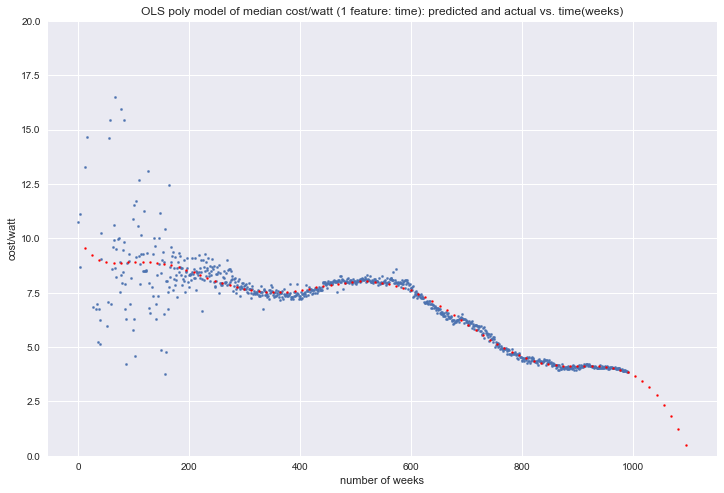

In [42]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'OLS poly model of median cost/watt (1 feature: time): predicted and actual vs. time(weeks)'
ax.set_title(sTitle)
# actual
ax.scatter(X, y, marker='o', s=5, alpha=1)
# predicted
ax.scatter(theX, theY, s=4, alpha=1.0, marker='o', color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of weeks')
ax.set_ylim(0, 20)
plt.show;

---

---

---
### OLS Polynomial of median cost/watt (2 features, time in months, size group)

---

In [43]:
# get the median by month and size
by_month_size = dfMod.groupby(['num_months', 'scaleSize'])
med_by_month_size = by_month_size.cost_per_watt.median()
# use a df to make accessing features easier
dfMedByMonthSize = pd.DataFrame(med_by_month_size).reset_index(); dfMedByMonthSize.head()

,num_months,scaleSize,cost_per_watt
0,0.0,0.0,10.921508
1,1.0,0.0,8.667013
2,3.0,0.0,13.962563
3,6.0,1.0,6.858942
4,7.0,0.0,6.768190


In [44]:
# make a poly expansion of median (8th degree) with scaling and LR
medMS = Pipeline([('scale', StandardScaler()),
                         ('poly', PolynomialFeatures()),
                         ('LR', LinearRegression())])

medMS.set_params(poly__degree=8)

Pipeline(memory=None,
     steps=[('scale', StandardScaler(copy=True, with_mean=True, with_std=True)), ('poly', PolynomialFeatures(degree=8, include_bias=True, interaction_only=False)), ('LR', LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False))])

In [45]:
### Yes, looking at the real data grouped by month and scale size, agg'ed by median
X = dfMedByMonthSize[['num_months', 'scaleSize']]
y = dfMedByMonthSize[['cost_per_watt']].values
X.shape, y.shape

((1778, 2), (1778, 1))

In [46]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=21)

# Train the model
medMS.fit(X_train, y_train)
# Predict on the test set
yhat = medMS.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(medMS.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("RMSE: {:.4f}".format(rmse))

R^2: 0.8512
RMSE: 0.7236


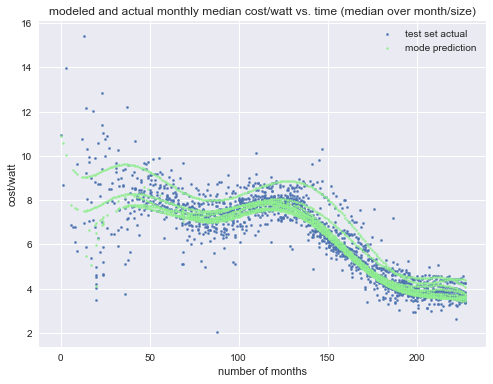

In [47]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'modeled and actual monthly median cost/watt vs. time (median over month/size)'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_months, y, marker='o', s=5, alpha=1, label='test set actual')
ax.scatter(X.num_months, medMS.predict(X), s=4, alpha=1, color='lightgreen', label='mode prediction')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of months')
ax.legend()
plt.show();

#### predict on data including time extrapolation and 3 most common size groups

### Extrapolate 2017 and 2018

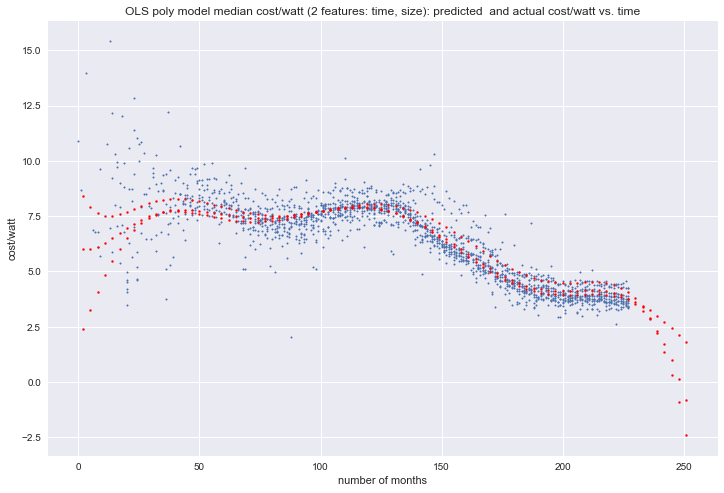

In [48]:
# grab month and size 
# (only need the first half because we're ignoring state)
theX = predData[['num_months', 'scaleSize']][:252]

# poly8.fit_transform(theX.values.reshape(-1, 1))
theY = medMS.predict(theX.values)

# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'OLS poly model median cost/watt (2 features: time, size): predicted  and actual cost/watt vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_months, y, marker='.', s=10, alpha=1.0)

# predicted
ax.scatter(theX.num_months, theY, s=4, alpha=1.0, marker='o', color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of months')
#ax.set_ylim(-10, 20)
plt.show;

---
---

---
### OLS Polynomial of median cost/watt (2 features: time in weeks, size group)

---

In [49]:
# get the median by week and size
by_week_size = dfMod.groupby(['num_weeks', 'scaleSize'])
med_by_week_size = by_week_size.cost_per_watt.median()
# use a df to make accessing features easier
dfMedByWeekSize = pd.DataFrame(med_by_week_size).reset_index(); dfMedByWeekSize.head()

,num_weeks,scaleSize,cost_per_watt
0,0.0,0.0,10.734315
1,3.0,0.0,11.108701
2,4.0,0.0,8.667013
3,12.0,0.0,13.270286
4,16.0,0.0,14.654839


In [50]:
# make a poly expansion of median (8th degree) with scaling and LR
medWS = Pipeline([('scale', StandardScaler()),
                  ('poly', PolynomialFeatures()),
                  ('LR', LinearRegression())])

medWS.set_params(poly__degree=8)

Pipeline(memory=None,
     steps=[('scale', StandardScaler(copy=True, with_mean=True, with_std=True)), ('poly', PolynomialFeatures(degree=8, include_bias=True, interaction_only=False)), ('LR', LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False))])

In [51]:
### Yes, looking at the real data grouped by week and scale size, agg'ed by median
X = dfMedByWeekSize[['num_weeks', 'scaleSize']]
y = dfMedByWeekSize[['cost_per_watt']].values
X.shape, y.shape

((6598, 2), (6598, 1))

In [52]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=21)

# Train the model
medWS.fit(X_train, y_train)
# Predict on the test set
yhat = medWS.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(medWS.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("RMSE: {:.4f}".format(rmse))

R^2: 0.8386
RMSE: 0.7559


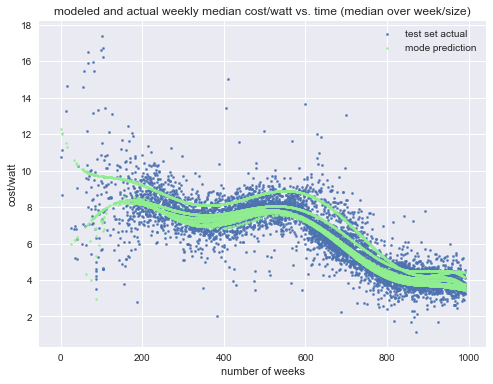

In [53]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'modeled and actual weekly median cost/watt vs. time (median over week/size)'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_weeks, y, marker='o', s=5, alpha=1, label='test set actual')
# predicted
ax.scatter(X.num_weeks, medWS.predict(X), s=4, alpha=1, color='lightgreen', label='mode prediction')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of weeks')
ax.legend()
plt.show();

#### predict on data including time extrapolation and 3 most common size groups

### Extrapolate 2017 and 2018

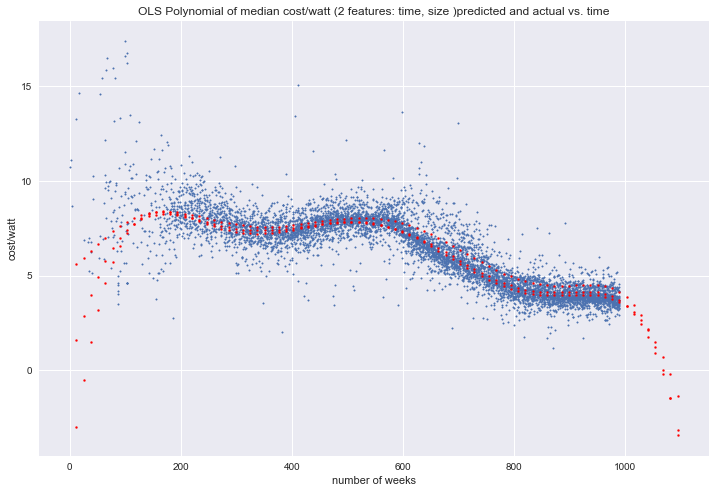

In [54]:
# grab week and size 
# (only need the first half because we're ignoring state)
theX = predData[['num_weeks', 'scaleSize']][:252]

# poly8.fit_transform(theX.values.reshape(-1, 1))
theY = medWS.predict(theX.values)

# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'OLS Polynomial of median cost/watt (2 features: time, size )predicted and actual vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_weeks, y, marker='.', s=10, alpha=1.0)

# predicted
ax.scatter(theX.num_weeks, theY, s=4, alpha=1.0, marker='o', color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of weeks')
#ax.set_ylim(-10, 20)
plt.show;

---
---